In [ ]:
# Notebook setup
import sys
from pathlib import Path
base = Path.cwd()
source = next((p for p in (base, *base.parents) if (p / "code/pyproject.toml").is_file()), base / "Release-Client.zip")
if not source.exists() and "google.colab" in sys.modules:
    from google.colab import files
    print("Required file: Release-Client.zip (project code). Choose this ZIP; data files are requested next.", flush=True)
    files.upload(target_dir=str(base))
if not source.exists():
    raise FileNotFoundError("Supply Release-Client.zip, or open the extracted code/notebooks folder.")
sys.path.insert(0, str(source / "cost-aware-market-forecasting" if source.is_file() else source))
sys.modules.pop("run_zip", None)
from run_zip import prepare_reader
CODE = CODE_ROOT = prepare_reader('20_RQ5_C_BTC_economic_direction_head.ipynb', source, ())

# 20 - RQ5_C: BTC economic direction head

## Methodology

Frozen timing activations from Notebook 19 determine when to trade; LogReg and XGBoost choose LONG or SHORT at every scored activation, without abstention. A fixed 28-feature causal contract uses six expanding, purged development folds after a 2022-H1 warm-up. Both sides share RR2, a 120-minute horizon and 10 bps round-trip costs. Economic means and paired episode-cluster intervals assess whether learned direction improves on channel-side direction.


In [2]:
from experiments.channel_rebuild_contract import recomputed_handoffs
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

RUN_ROOT_BASE = 'code'
RUN_ROOT_RELATIVE = 'experiments/cache/event_window_direction_head'
if RUN_ROOT_BASE == "code":
    RUN_ROOT = (CODE_ROOT / RUN_ROOT_RELATIVE).resolve()
else:
    RUN_ROOT = (Path.cwd().resolve() / RUN_ROOT_RELATIVE).resolve()

EXPECTED_FRAME_COLUMNS = {'geometry_audit.csv': ('geometry', 'primary', 'diagnostic_only', 'target_multiple_b', 'hold_minutes', 'entry_cost_bps', 'exit_cost_bps', 'round_trip_cost_bps', 'native_one_minute', 'stop_first', 'executed', 'path_completeness', 'smoke_deferred'), 'feature_audit.csv': ('feature', 'position', 'included', 'known_at_decision_time', 'future_column', 'finite_fraction'), 'correlation_audit.csv': ('feature_left', 'feature_right', 'spearman', 'abs_spearman', 'diagnostic_only'), 'fold_audit.csv': ('fold_id', 'train_fit_rows', 'validation_rows', 'train_episodes', 'validation_episodes', 'episode_overlap', 'train_label_end_max', 'validation_start'), 'predictive_metrics.csv': ('model', 'scored_rows', 'raw_sign_accuracy', 'value_weighted_sign_accuracy', 'mae_delta_r', 'rmse_delta_r'), 'economic_metrics.csv': ('scenario', 'activations', 'path_completeness', 'mean_net_r', 'total_net_r', 'mean_net_bps', 'mean_net_r_ci_low', 'mean_net_r_ci_high', 'mean_oracle_regret_r', 'oracle_value_capture'), 'paired_bootstrap.csv': ('comparison', 'candidate', 'baseline', 'point_mean_net_r', 'ci_low', 'ci_high', 'draws', 'bootstrap_unit'), 'frequency_audit.csv': ('scenario', 'activations', 'unique_activation_keys', 'activations_per_day', 'keys_equal_frozen', 'timing_owned_by_frozen_u'), 'concurrency_audit.csv': ('source', 'activations', 'hold_minutes', 'mean_active_at_entry', 'maximum_active_at_entry', 'overlap_fraction', 'capacity_suppression'), 'leakage_audit.csv': ('check', 'passed', 'detail')}
EXPECTED_PARQUET_COLUMNS = {'direction_dataset.parquet': ('activation_key', 'fold_id', 'best_side', 'delta_r', 'economic_value'), 'economic_paths.parquet': ('activation_key', 'direction', 'geometry', 'outcome', 'net_r', 'cost_bps'), 'oof_direction_predictions.parquet': ('model', 'fold_id', 'activation_key', 'direction_score', 'chosen_direction'), 'policy_paths.parquet': ('scenario', 'activation_key', 'chosen_direction', 'net_r'), 'combined_policy_ledger.parquet': ('model', 'activation_key', 'decision_time', 'threshold', 'activation_score', 'chosen_direction')}
REQUIRED_READER_ARTIFACTS = ('direction_dataset.parquet', 'economic_paths.parquet', 'geometry_audit.csv', 'feature_audit.csv', 'correlation_audit.csv', 'fold_audit.csv', 'oof_direction_predictions.parquet', 'predictive_metrics.csv', 'policy_paths.parquet', 'combined_policy_ledger.parquet', 'economic_metrics.csv', 'paired_bootstrap.csv', 'frequency_audit.csv', 'concurrency_audit.csv', 'leakage_audit.csv', 'protocol.json', 'frozen_protocol.json', 'summary.json')

def _sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def _candidate_run_dirs():
    candidates = []
    pointer_path = RUN_ROOT / "latest_dev.json"
    if pointer_path.is_file():
        pointer = json.loads(pointer_path.read_text(encoding="utf-8"))
        run_hash = str(pointer.get("run_hash", ""))
        protocol_hash = str(pointer.get("protocol_hash", ""))
        relative_path = Path(str(pointer.get("relative_path", "")))
        if relative_path.is_absolute() or ".." in relative_path.parts:
            raise ValueError("completed-run pointer path is unsafe")
        run_dir = (RUN_ROOT / relative_path).resolve()
        if run_dir != (RUN_ROOT / run_hash / "full").resolve():
            raise ValueError("completed-run pointer does not identify its full run")
        candidates.append((run_dir, run_hash, protocol_hash, False))
    smoke_states = sorted(
        RUN_ROOT.glob("*/smoke/run_state.json"),
        key=lambda path: path.stat().st_mtime_ns,
        reverse=True,
    )
    for state_path in smoke_states:
        candidates.append((state_path.parent, state_path.parent.parent.name, None, True))
    return candidates

def _load_candidate(run_dir, run_hash, pointer_protocol_hash, smoke):
    state = json.loads((run_dir / "run_state.json").read_text(encoding="utf-8"))
    if state.get("status") != "complete" or state.get("run_hash") != run_hash:
        raise ValueError("run state is not complete or its identity changed")
    if pointer_protocol_hash is not None and state.get("protocol_hash") != pointer_protocol_hash:
        raise ValueError("completed-run pointer protocol does not match")
    records = state.get("artifacts", {})
    for name in REQUIRED_READER_ARTIFACTS:
        path = run_dir / name
        record = records.get(name, {})
        if not path.is_file() or not record:
            raise ValueError(f"required artifact is missing: {name}")
        if int(record.get("size", -1)) != path.stat().st_size:
            raise ValueError(f"artifact size does not match: {name}")
        if str(record.get("sha256", "")) != _sha256(path):
            raise ValueError(f"artifact hash does not match: {name}")

    protocol = json.loads((run_dir / "protocol.json").read_text(encoding="utf-8"))
    frozen = json.loads((run_dir / "frozen_protocol.json").read_text(encoding="utf-8"))
    summary = json.loads((run_dir / "summary.json").read_text(encoding="utf-8"))
    if state.get("summary") != summary:
        raise ValueError("summary does not match the completed run state")
    if any(protocol.get(name) != state.get(name) for name in (
        "run_hash", "protocol_hash", "source_hash", "input_hash"
    )):
        raise ValueError("protocol identity does not match the completed run state")
    if protocol.get("study") != "notebook_v_economic_direction_value_head":
        raise ValueError("artifact study is not Notebook V")
    if protocol.get("stage") != "dev" or bool(protocol.get("smoke")) != smoke:
        raise ValueError("artifact execution mode does not match its run location")
    if protocol.get("frozen_u_run_hash") != frozen.get("frozen_u_run_hash"):
        raise ValueError("frozen Notebook U identity does not reconcile")
    for payload in (protocol, frozen, summary):
        if payload.get("forward_or_lockbox_loaded") is not False:
            raise ValueError("later-period data are not accepted")
    required_protocol = {
        "direction_feature_count": 28,
        "entry_cost_bps": 5.0,
        "target_exit_cost_bps": 5.0,
        "other_exit_cost_bps": 5.0,
        "round_trip_cost_bps": 10.0,
        "hold_minutes": 120,
        "target_multiple_b": 2.0,
        "forced_direction": True,
        "trade_gate_included": False,
        "threshold_search": False,
        "timing_model_refit": False,
    }
    if any(protocol.get(key) != value for key, value in required_protocol.items()):
        raise ValueError("Notebook V frozen reader protocol changed")
    required_summary = {
        "source_activations": int(protocol["expected_source_activations"]) if recomputed_handoffs() else 3431,
        "scored_activations": int(protocol["expected_scored_activations"]) if recomputed_handoffs() else 2939,
        "warmup_activations": int(protocol["expected_source_activations"]) - int(protocol["expected_scored_activations"]) if recomputed_handoffs() else 492,
        "direction_feature_count": 28,
        "round_trip_cost_bps": 10.0,
        "timing_model_refit": False,
        "timing_frequency_changed": False,
        "trade_gate_included": False,
        "forced_direction": True,
    }
    if any(summary.get(key) != value for key, value in required_summary.items()):
        raise ValueError("Notebook V completed summary changed")
    if smoke:
        if summary.get("research_claim") != "smoke_only_no_claim":
            raise ValueError("smoke artifacts were not marked non-evidential")
        if summary.get("selected_model") is not None:
            raise ValueError("smoke artifacts may not select a direction model")
    elif summary.get("research_claim") != "development_result":
        raise ValueError("full development artifacts lack their result provenance")

    frames = {}
    for name, required_columns in EXPECTED_FRAME_COLUMNS.items():
        frame = pd.read_csv(run_dir / name)
        missing = [column for column in required_columns if column not in frame]
        if missing:
            raise ValueError(f"artifact schema does not match: {name}: {missing}")
        frames[name] = frame
    parquets = {}
    for name, required_columns in EXPECTED_PARQUET_COLUMNS.items():
        frame = pd.read_parquet(run_dir / name)
        missing = [column for column in required_columns if column not in frame]
        if missing:
            raise ValueError(f"artifact schema does not match: {name}: {missing}")
        parquets[name] = frame

    feature_audit = frames["feature_audit.csv"]
    if len(feature_audit) != 28 or feature_audit["position"].tolist() != list(range(28)):
        raise ValueError("28-feature audit order changed")
    for column in ("included", "known_at_decision_time"):
        if not feature_audit[column].astype(bool).all():
            raise ValueError(f"feature audit failed: {column}")
    if feature_audit["future_column"].astype(bool).any():
        raise ValueError("feature audit contains a future field")
    if not frames["leakage_audit.csv"]["passed"].astype(bool).all():
        raise ValueError("leakage audit contains a failed check")
    if not frames["frequency_audit.csv"]["keys_equal_frozen"].astype(bool).all():
        raise ValueError("direction policy changed frozen activation keys")
    if set(parquets["combined_policy_ledger.parquet"]["chosen_direction"]) - {"long", "short"}:
        raise ValueError("combined policy contains an action other than LONG/SHORT")
    # JSON stores metadata only; analytical rows remain in validated Parquet and CSV artifacts.
    return run_dir, protocol, frozen, summary, frames, parquets, smoke

def _load_completed_run():
    errors = []
    try:
        candidates = _candidate_run_dirs()
    except Exception as error:
        return None, None, None, None, {}, {}, None, str(error)
    for candidate in candidates:
        try:
            loaded = _load_candidate(*candidate)
            return (*loaded, None)
        except Exception as error:
            errors.append(str(error))
    note = errors[0] if errors else "no completed full or smoke run was found"
    return None, None, None, None, {}, {}, None, note

(RUN_DIR, PROTOCOL, FROZEN, SUMMARY, FRAMES, PARQUETS,
 RUN_IS_SMOKE, READER_NOTE) = _load_completed_run()
READER_READY = RUN_DIR is not None
if READER_READY and RUN_IS_SMOKE:
    EVIDENCE_LABEL = "SMOKE / NON-EVIDENTIAL"
    print(f"Loaded completed Notebook V smoke run: {RUN_DIR.parent.name}")
    print("SMOKE / NON-EVIDENTIAL: structural reader execution only; no economic claim.")
elif READER_READY:
    EVIDENCE_LABEL = "FULL DEVELOPMENT EVIDENCE"
else:
    EVIDENCE_LABEL = "ARTIFACTS UNAVAILABLE"
    print(f"Completed Notebook V artifacts are not available: {READER_NOTE}.")

## Fixed geometry

Each activation retains its timing key, score and threshold and is replayed LONG and SHORT with adaptive 1B risk, RR2 and a 120-minute native one-minute path. Same-minute ambiguity is resolved stop-first. Entry and exit each cost 5 bps. Fixed 75 and 120 bps barriers are diagnostic; the oracle is an unattainable hindsight reference.


In [3]:
from IPython.display import Markdown
if READER_READY:
    geometry = FRAMES["geometry_audit.csv"].copy()
    display(Markdown('Both sides are replayed at each frozen timing activation with RR2, a 120-minute horizon and 10 bps costs.'))
    display(geometry[[
        "geometry", "primary", "diagnostic_only", "target_multiple_b",
        "hold_minutes", "round_trip_cost_bps", "native_one_minute",
        "stop_first", "executed", "path_completeness", "smoke_deferred",
    ]])
    oracle = FRAMES["economic_metrics.csv"].loc[
        FRAMES["economic_metrics.csv"]["scenario"].eq("oracle"),
        ["scenario", "activations", "path_completeness", "mean_net_r",
         "mean_net_r_ci_low", "mean_net_r_ci_high"],
    ]
    display(Markdown('The oracle chooses the better realised side after the event and is an unattainable reference.'))
    display(oracle)
else:
    pass

Both sides are replayed at each frozen timing activation with RR2, a 120-minute horizon and 10 bps costs.

,geometry,primary,diagnostic_only,target_multiple_b,hold_minutes,round_trip_cost_bps,native_one_minute,stop_first,executed,path_completeness,smoke_deferred
0,adaptive_primary,True,False,2.0,120,10.0,True,True,True,1.0,False
1,fixed_75bps_diagnostic,False,True,2.0,120,10.0,True,True,True,1.0,False
2,fixed_120bps_diagnostic,False,True,2.0,120,10.0,True,True,True,1.0,False


The oracle chooses the better realised side after the event and is an unattainable reference.

,scenario,activations,path_completeness,mean_net_r,mean_net_r_ci_low,mean_net_r_ci_high
6,oracle,2939,1.0,0.476479,0.453903,0.500456


## Economic target and features

The target is `delta_r = net_r_long - net_r_short`; its sign defines the better side and `min(abs(delta_r), 3)` defines the economic weight. The fixed 28-feature contract includes the activation margin. Outcomes are labels only; preprocessing is fold-local and feature correlation is diagnostic.


The table defines each direction feature, its finite-data fraction and whether it is available before the decision.

,position,feature,finite_fraction,known_at_decision_time,future_column
0,0,raw_log_return,1.000000,True,False
1,1,raw_log_return_mean_3,1.000000,True,False
2,2,raw_log_return_mean_12,1.000000,True,False
3,3,raw_log_return_mean_24,1.000000,True,False
4,4,raw_body_bps,1.000000,True,False
5,5,lower_wick_fraction,1.000000,True,False
6,6,upper_wick_fraction,1.000000,True,False
7,7,raw_taker_imbalance,1.000000,True,False
8,8,raw_taker_imbalance_mean_3,1.000000,True,False
9,9,raw_taker_imbalance_mean_12,1.000000,True,False


Target summaries describe the realised LONG-minus-SHORT Net R and clipped economic weights.

,count,mean,std,min,25%,50%,75%,max
delta_r,3431.0,0.002581,1.433732,-3.0,-0.932778,0.062992,0.927343,3.0
economic_value,3431.0,1.136586,0.873722,0.0,0.401876,0.930741,1.745300,3.0


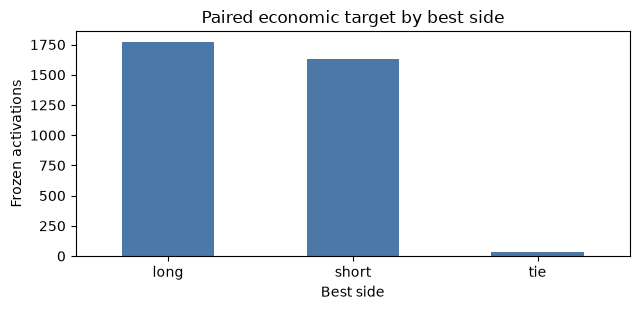

Feature correlations are diagnostic and do not drive outcome-based feature selection.

,feature_left,feature_right,spearman,diagnostic_only
3,raw_log_return,raw_body_bps,0.999989,True
287,raw_channel_position,raw_distance_mid_bps,0.946494,True
0,raw_log_return,raw_log_return_mean_3,0.839338,True
29,raw_log_return_mean_3,raw_body_bps,0.839209,True
27,raw_log_return_mean_3,raw_log_return_mean_12,0.768260,True
53,raw_log_return_mean_12,raw_log_return_mean_24,0.768137,True
104,raw_body_bps,raw_taker_imbalance,0.741179,True
6,raw_log_return,raw_taker_imbalance,0.741156,True
245,raw_channel_slope,raw_distance_mid_bps,-0.736679,True
168,raw_taker_imbalance,raw_taker_imbalance_mean_3,0.723234,True


In [4]:
from IPython.display import Markdown
if READER_READY:
    feature_audit = FRAMES["feature_audit.csv"].copy()
    display(Markdown('The table defines each direction feature, its finite-data fraction and whether it is available before the decision.'))
    display(feature_audit[[
        "position", "feature", "finite_fraction", "known_at_decision_time",
        "future_column",
    ]])
    direction = PARQUETS["direction_dataset.parquet"]
    target_summary = direction[["delta_r", "economic_value"]].describe().T
    display(Markdown('Target summaries describe the realised LONG-minus-SHORT Net R and clipped economic weights.'))
    display(target_summary)
    side_counts = direction["best_side"].value_counts().reindex(
        ["long", "short", "tie"], fill_value=0
    )
    side_counts.plot(kind="bar", figsize=(6.5, 3.2), color="#4C78A8")
    plt.title("Paired economic target by best side")
    plt.xlabel("Best side")
    plt.ylabel("Frozen activations")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    correlations = FRAMES["correlation_audit.csv"].sort_values(
        "abs_spearman", ascending=False
    ).head(12)
    display(Markdown('Feature correlations are diagnostic and do not drive outcome-based feature selection.'))
    display(correlations[["feature_left", "feature_right", "spearman", "diagnostic_only"]])
else:
    pass

## Expanding training

A 2022-H1 warm-up precedes six expanding out-of-fold periods. Training uses earlier activations, a complete 120-minute label purge, episode-disjoint validation and interval-uniqueness weights. The table reports training and validation samples separately.


Six expanding tests follow a 2022-H1 warm-up and purge labels extending beyond each fit boundary.

,fold_id,train_fit_rows,validation_rows,train_episodes,validation_episodes,episode_overlap,train_label_end_max,validation_start
0,2022H2,484,236,74,54,0,2022-06-27 00:30:00+00:00,2022-07-01 00:00:00+00:00
1,2023H1,719,541,128,78,0,2022-12-23 15:35:00+00:00,2023-01-01 00:00:00+00:00
2,2023H2,1256,305,206,69,0,2023-06-30 19:20:00+00:00,2023-07-01 00:00:00+00:00
3,2024H1,1557,910,275,74,0,2023-12-29 17:45:00+00:00,2024-01-01 00:00:00+00:00
4,2024H2,2462,532,349,57,0,2024-06-30 14:40:00+00:00,2024-07-01 00:00:00+00:00
5,2025H1,2991,415,406,64,0,2024-12-26 10:10:00+00:00,2025-01-01 00:00:00+00:00


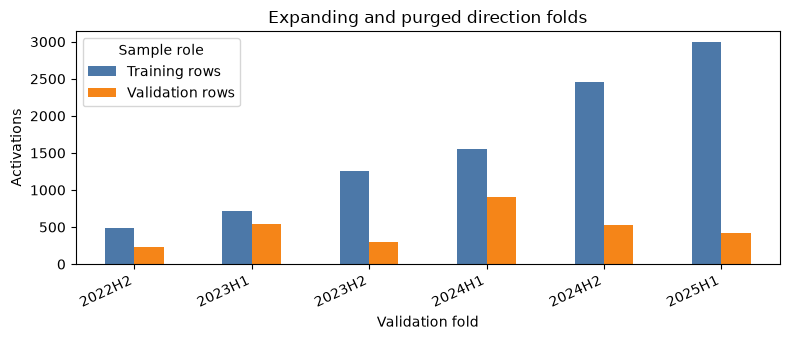

In [5]:
from IPython.display import Markdown
if READER_READY:
    folds = FRAMES["fold_audit.csv"].copy()
    display(Markdown('Six expanding tests follow a 2022-H1 warm-up and purge labels extending beyond each fit boundary.'))
    display(folds[[
        "fold_id", "train_fit_rows", "validation_rows", "train_episodes",
        "validation_episodes", "episode_overlap", "train_label_end_max",
        "validation_start",
    ]])
    fold_rows = folds.set_index("fold_id")[["train_fit_rows", "validation_rows"]]
    fold_rows.columns = ["Training rows", "Validation rows"]
    fold_rows.plot(kind="bar", figsize=(8, 3.5), color=["#4C78A8", "#F58518"])
    plt.title("Expanding and purged direction folds")
    plt.xlabel("Validation fold")
    plt.ylabel("Activations")
    plt.xticks(rotation=25, ha="right")
    plt.legend(title="Sample role")
    plt.tight_layout()
    plt.show()
else:
    pass

## Forced side choice

All models and baselines receive identical held-out activation keys and times. Every scored activation receives LONG or SHORT, without WAIT, threshold search or capacity suppression. Frequency is inherited from the frozen timing policy.


Every policy receives the same 2,939 held-out activation times, without abstention.

,scenario,activations,unique_activation_keys,activations_per_day,keys_equal_frozen,timing_owned_by_frozen_u
0,logreg,2939,2939,2.681569,True,True
1,xgboost,2939,2939,2.681569,True,True
2,channel_side,2939,2939,2.681569,True,True
3,always_long,2939,2939,2.681569,True,True
4,always_short,2939,2939,2.681569,True,True
5,random_50,2939,2939,2.681569,True,True
6,oracle,2939,2939,2.681569,True,True


Forced side choices are counted for each model on those identical activations.

chosen_direction,long,short
model,,
logreg,1886,1053
xgboost,1760,1179


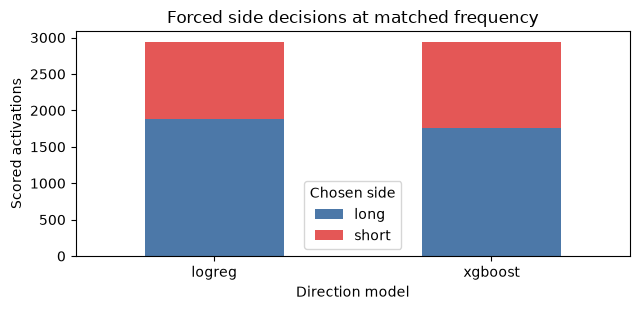

In [6]:
from IPython.display import Markdown
if READER_READY:
    frequency = FRAMES["frequency_audit.csv"].copy()
    display(Markdown('Every policy receives the same 2,939 held-out activation times, without abstention.'))
    display(frequency[[
        "scenario", "activations", "unique_activation_keys",
        "activations_per_day", "keys_equal_frozen", "timing_owned_by_frozen_u",
    ]])
    combined = PARQUETS["combined_policy_ledger.parquet"]
    side_counts = combined.groupby(["model", "chosen_direction"]).size().unstack(fill_value=0)
    display(Markdown('Forced side choices are counted for each model on those identical activations.'))
    display(side_counts)
    side_counts.plot(kind="bar", stacked=True, figsize=(6.5, 3.2),
                     color=["#4C78A8", "#E45756"])
    plt.title("Forced side decisions at matched frequency")
    plt.xlabel("Direction model")
    plt.ylabel("Scored activations")
    plt.xticks(rotation=0)
    plt.legend(title="Chosen side")
    plt.tight_layout()
    plt.show()
else:
    pass

## Predictive and economic evaluation

Mean net R after 10 bps costs is primary; side accuracy is secondary. Absolute and paired episode-cluster intervals compare each learned model with channel-side direction. Overlapping activations limit portfolio interpretation. Later-period fields refer to this development experiment; Q2 evaluation of the separately frozen policies is reported in Notebook 22.


Held-out side accuracy and value-weighted accuracy compare the two direction models.

,model,scored_rows,raw_sign_accuracy,value_weighted_sign_accuracy,mae_delta_r,rmse_delta_r
0,logreg,2939,0.518341,0.505578,Not estimable,Not estimable
1,xgboost,2939,0.509427,0.489238,1.133826,1.442719


Chosen-side paths are scored after 10 bps costs with episode-cluster intervals.

,scenario,activations,path_completeness,mean_net_r,mean_net_r_ci_low,mean_net_r_ci_high,mean_net_bps,mean_oracle_regret_r,oracle_value_capture
0,logreg,2939,1.0,-0.069433,-0.100010,-0.039857,-8.816520,0.545912,-0.145720
1,xgboost,2939,1.0,-0.087474,-0.112390,-0.063390,-10.760411,0.563953,-0.183584
2,channel_side,2939,1.0,-0.069904,-0.101347,-0.039727,-9.100861,0.546383,-0.146709
3,always_long,2939,1.0,-0.067901,-0.097118,-0.038286,-7.978730,0.544380,-0.142506
4,always_short,2939,1.0,-0.083282,-0.112896,-0.052692,-10.567293,0.559762,-0.174787
5,random_50,2939,1.0,-0.084873,-0.112511,-0.057112,-10.346758,0.561352,-0.178124
6,oracle,2939,1.0,0.476479,0.453903,0.500456,61.217711,0.000000,1.000000


Absolute and paired means use 2,000 channel-episode bootstrap resamples.

,comparison,point_mean_net_r,ci_low,ci_high,draws,bootstrap_unit
0,absolute::logreg,-0.069433,-0.100010,-0.039857,2000,channel_episode_id
1,absolute::xgboost,-0.087474,-0.112390,-0.063390,2000,channel_episode_id
2,absolute::channel_side,-0.069904,-0.101347,-0.039727,2000,channel_episode_id
3,absolute::always_long,-0.067901,-0.097118,-0.038286,2000,channel_episode_id
4,absolute::always_short,-0.083282,-0.112896,-0.052692,2000,channel_episode_id
5,absolute::random_50,-0.084873,-0.112511,-0.057112,2000,channel_episode_id
6,absolute::oracle,0.476479,0.453903,0.500456,2000,channel_episode_id
7,logreg_minus_channel_side,0.000471,-0.034446,0.035245,2000,channel_episode_id
8,xgboost_minus_channel_side,-0.017570,-0.052134,0.018076,2000,channel_episode_id
9,xgboost_minus_logreg,-0.018041,-0.046492,0.009077,2000,channel_episode_id


Concurrent activations are counted without applying a new capacity filter.

,source,activations,hold_minutes,mean_active_at_entry,maximum_active_at_entry,overlap_fraction,capacity_suppression
0,xgboost_base,2939,120,1.461722,3,0.461381,False


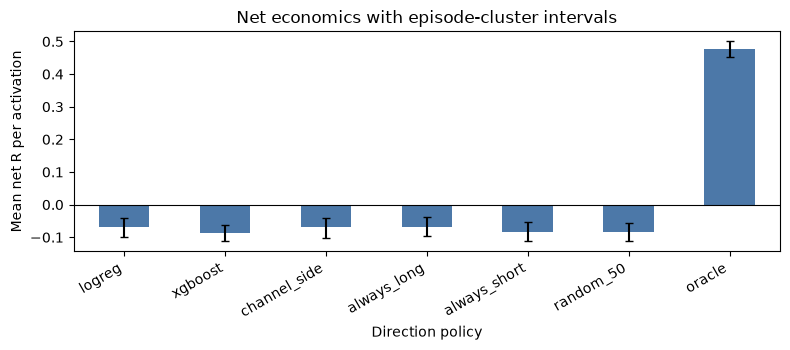

The decision summarises economic viability and unchanged timing. The later-period flag applies only to this development experiment.

,Notebook V frozen decision
evidence label,FULL DEVELOPMENT EVIDENCE
decision,negative direction result; add no trade gate
selected direction model,None
LogReg viable,False
XGBoost viable,False
frozen source activations,3431
scored activations,2939
timing frequency changed,False
trade gate included,False
forward or Q2 loaded,False


In [7]:
from IPython.display import Markdown
if READER_READY:
    predictive = FRAMES["predictive_metrics.csv"].copy()
    display(Markdown('Held-out side accuracy and value-weighted accuracy compare the two direction models.'))
    display((predictive[[
        "model", "scored_rows", "raw_sign_accuracy",
        "value_weighted_sign_accuracy", "mae_delta_r", "rmse_delta_r",
    ]]).fillna('Not estimable'))
    economics = FRAMES["economic_metrics.csv"].copy()
    display(Markdown('Chosen-side paths are scored after 10 bps costs with episode-cluster intervals.'))
    display(economics[[
        "scenario", "activations", "path_completeness", "mean_net_r",
        "mean_net_r_ci_low", "mean_net_r_ci_high", "mean_net_bps",
        "mean_oracle_regret_r", "oracle_value_capture",
    ]])
    paired = FRAMES["paired_bootstrap.csv"].copy()
    display(Markdown('Absolute and paired means use 2,000 channel-episode bootstrap resamples.'))
    display(paired[[
        "comparison", "point_mean_net_r", "ci_low", "ci_high", "draws",
        "bootstrap_unit",
    ]])
    display(Markdown('Concurrent activations are counted without applying a new capacity filter.'))
    display(FRAMES["concurrency_audit.csv"])
    leakage = FRAMES["leakage_audit.csv"]

    chart = economics.set_index("scenario")
    lower_error = np.maximum(0.0, chart["mean_net_r"] - chart["mean_net_r_ci_low"])
    upper_error = np.maximum(0.0, chart["mean_net_r_ci_high"] - chart["mean_net_r"])
    chart["mean_net_r"].plot(
        kind="bar", yerr=np.vstack([lower_error, upper_error]), capsize=3,
        figsize=(8, 3.6), color="#4C78A8",
    )
    plt.axhline(0.0, color="black", linewidth=0.8)
    plt.title("Net economics with episode-cluster intervals")
    plt.xlabel("Direction policy")
    plt.ylabel("Mean net R per activation")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    decision = pd.Series({
        "evidence label": EVIDENCE_LABEL,
        "decision": SUMMARY["decision"],
        "selected direction model": SUMMARY["selected_model"],
        "LogReg viable": SUMMARY["model_viability"]["logreg"],
        "XGBoost viable": SUMMARY["model_viability"]["xgboost"],
        "frozen source activations": SUMMARY["source_activations"],
        "scored activations": SUMMARY["scored_activations"],
        "timing frequency changed": SUMMARY["timing_frequency_changed"],
        "trade gate included": SUMMARY["trade_gate_included"],
        "forward or Q2 loaded": SUMMARY["forward_or_lockbox_loaded"],
    }, name="Notebook V frozen decision")
    display(Markdown('The decision summarises economic viability and unchanged timing. The later-period flag applies only to this development experiment.'))
    display(decision.to_frame())
else:
    pass

## Results

The two models score 2,939 held-out activations at 2.6816 per day. LogReg returns -0.069433 mean net R and XGBoost -0.087474; both absolute intervals lie below zero. Their paired differences from channel-side direction have intervals crossing zero. The positive oracle result uses realised outcomes and is not attainable by the learned policies.

Takeaway: Forced learned direction does not establish profitable execution or an improvement over channel-side direction.
